# **Data Understanding**
This notebook contains the analysis of the texts, from their sizes to the overall token frequencies. At the end, a method is proposed in order to create the snapshots and save the results.

In [8]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
import random
import numpy as np
import re

## 1. Paragraphs analysis

In [ ]:
input_dir = Path("dataset/release/year_spacy_split")

paragraph_counts = []
years = []


for dir_name in sorted(input_dir.iterdir()):
    year = dir_name.stem.split("_")[-1]  # un_1949 -> 1949
    cur_count = 0
    
    for file in dir_name.iterdir():
        with open(file, "r", encoding="utf-8") as f:
            text = f.read()

        # Count paragraphs by counting <p> tags
        cur_count += text.count("<p>")
        
    paragraph_counts.append(cur_count)
    years.append(int(year))

# Display neatly
for year, count in zip(years, paragraph_counts):
    print(f"{year}: {count} paragraphs")

1948: 24578 paragraphs
1949: 36592 paragraphs
1950: 37499 paragraphs
1951: 63050 paragraphs
1952: 69724 paragraphs
1953: 74478 paragraphs
1954: 59586 paragraphs
1955: 53118 paragraphs
1956: 42457 paragraphs
1957: 58246 paragraphs
1958: 25146 paragraphs
1959: 32681 paragraphs
1960: 29769 paragraphs
1961: 32592 paragraphs
1962: 43874 paragraphs
1963: 82762 paragraphs
1964: 112807 paragraphs
1965: 73525 paragraphs
1966: 80325 paragraphs
1967: 93734 paragraphs
1968: 92141 paragraphs
1969: 55821 paragraphs
1970: 45488 paragraphs
1971: 112327 paragraphs
1972: 169070 paragraphs
1973: 153352 paragraphs
1974: 201277 paragraphs
1975: 162034 paragraphs
1976: 307458 paragraphs
1977: 214747 paragraphs
1978: 228656 paragraphs
1979: 320298 paragraphs
1980: 281755 paragraphs
1981: 125525 paragraphs
1982: 128058 paragraphs
1983: 167408 paragraphs
1984: 142414 paragraphs
1985: 150414 paragraphs
1986: 164668 paragraphs
1987: 248370 paragraphs
1988: 239112 paragraphs
1989: 248147 paragraphs
1990: 248841 p

In [10]:
min_idx = paragraph_counts.index(min(paragraph_counts))
max_idx = paragraph_counts.index(max(paragraph_counts))

min_year = years[min_idx]
max_year = years[max_idx]

min_count = paragraph_counts[min_idx]
max_count = paragraph_counts[max_idx]

print(f"Year with fewest paragraphs: {min_year} ({min_count})")
print(f"Year with most paragraphs:   {max_year} ({max_count})")

Year with fewest paragraphs: 1948 (24578)
Year with most paragraphs:   1979 (320298)


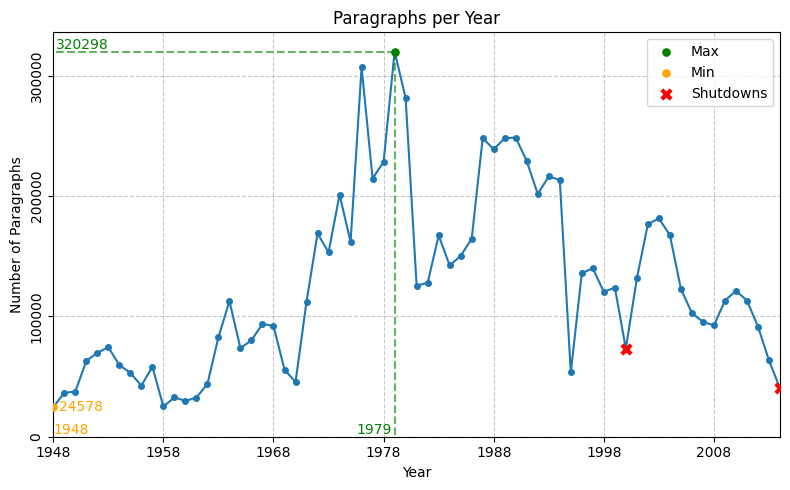

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(years, paragraph_counts, marker='o',
         markersize=4, linestyle='-')

# X-axis: show only some xticks
xticks = years[::10]
plt.xticks(xticks, )

# Y-axis: rotate labels
y_ticks = range(0, 400000, 100000)
plt.yticks(y_ticks, rotation=90, va='center', ha='right')

# --- Projection lines only toward axes (L-shaped) ---
# Max point
plt.scatter(max_year, max_count, label='Max', c='green', s=27, zorder=5)
# Vertical line down to x-axis
plt.plot([max_year, max_year], [max_count, 0], color='green', linestyle='--', alpha=0.6)
# Horizontal line y-axis to point
plt.plot([max_year, years[0]], [max_count, max_count], color='green', linestyle='--', alpha=0.6)
# Labels on axes
plt.text(max_year - 1.9, 0.3, f"{max_year}", color='green', fontsize=10, ha='center', va='bottom')  # x-axis
plt.text(years[0] + 0.2, max_count, f"{max_count}", color='green', fontsize=10, ha='left', va='bottom')  # y-axis

# Min point
plt.scatter(min_year, min_count, label='Min', c='orange', s=27, zorder=5)
plt.plot([min_year, min_year], [0, min_count], color='orange', linestyle='--', alpha=0.6)
plt.plot([min_year, years[0]], [min_count, min_count], color='orange', linestyle='--', alpha=0.6)
plt.text(min_year, 0, f"{min_year}", color='orange', fontsize=10, ha='left', va='bottom')
plt.text(years[0] + 0.5, min_count, f"{min_count}", color='orange', fontsize=10, ha='left', va='center')

# First shutdown
shutdown_years = [2000, 2014]
shutdown_idcs = [years.index(year) for year in shutdown_years]
shutdown_counts = [paragraph_counts[idx] for idx in shutdown_idcs]
plt.scatter(
    shutdown_years, shutdown_counts, label='Shutdowns',
    c='red', s=45, zorder=5, marker='x', linewidths=3
)


plt.xlabel("Year")
plt.ylabel("Number of Paragraphs")
plt.title("Paragraphs per Year")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(left=years[0], right=years[-1])
plt.ylim(bottom=0)
plt.tight_layout()
plt.legend()
plt.show()

- **prima crisi**: 2000
- **riapertura**: 2001
- **seconda chiusura**: 2014

## 2. Dictionary analysis

not enough values to unpack (expected 2, got 1)
639132
not enough values to unpack (expected 2, got 1)
802748
, 15151080
di 13277408
. 12322561
e 8889016
che 7768203
la 6040244
del 5772044
il 5565336
per 4818812
della 4639580


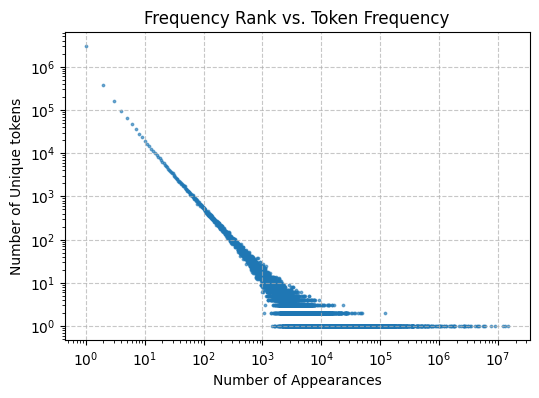

In [ ]:
dir = 'dataset/dict_all'

def plot_dict(name):
    word_counts = {}
    
    # Open the file
    with open(f'{dir}/{name}', "r", encoding="utf-8") as f:
        count = 0
        for line in f:
            # Remove leading/trailing whitespace
            line = line.strip()
            if not line:
                continue  # skip empty lines
            
            try:
                # Split on whitespace (tab or space)
                key, value = line.split()
                # Convert value to int
                word_counts[key] = int(value)
            except Exception as e:
                print(e)
                print(count)
            count += 1

    # Example: print first 10 items
    for k, v in list(word_counts.items())[:10]:
        print(k, v)
        
    counts = list(word_counts.values())
    freq_of_counts = Counter(counts)

    # Step 3: prepare x and y for scatter
    x = list(freq_of_counts.keys())  # number of appearances
    y = list(freq_of_counts.values())  # how many words have this frequency

    # Step 4: plot
    plt.figure(figsize=(6,4))
    plt.scatter(x, y, alpha=0.6, s=3)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Number of Appearances')
    plt.ylabel('Number of Unique tokens')
    plt.title('Frequency Rank vs. Token Frequency')
    plt.grid(linestyle='--', alpha=0.7)
    plt.show()

plot_dict('token_all.dict')

not enough values to unpack (expected 2, got 1)
not enough values to unpack (expected 2, got 1)
, 15151080
di 13583424
. 12322561
il 10389640
e 8889016
la 8662694
essere 7814954
che 7768203
della 7465540
del 6967123


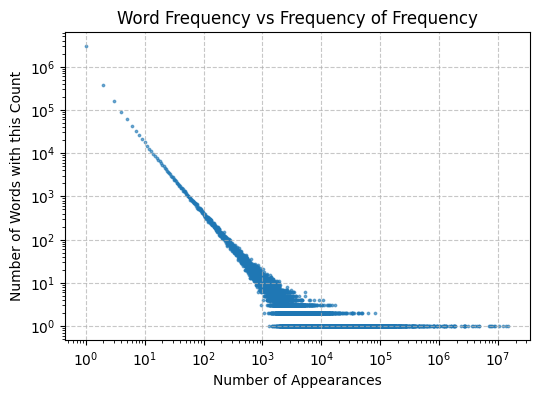

In [175]:
plot_dict('lemma_all.dict')

In [ ]:
# Get parent directory
path = os.path.abspath(os.getcwd())
parent = os.path.dirname(os.path.dirname(path))

# Correctly join the path
input_f = os.path.join(parent, 'dataset', 'release', 'year_clean', 'un_1979')

# Read file content
with open(input_f, 'r') as f:
    text = f.read()

print(text[:200])  # print first 200 chars to check

Appello da Pisa : un voto al PCI per il riscatto del Mezzogiorno Uno sperpero di risorse material; e umane che deve finire - E' possibile cambiare dando fiducia alle liste del partito comunista - La r


In [ ]:
# 'text' is defined in a previous cell
tokens = re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)
total_words = len(tokens)
unique_tokens = len(set(tokens))
counts = Counter(tokens)

print(f"Total words: {total_words}")
print(f"Unique tokens: {unique_tokens}")
print("\nTop 20 tokens:")
for tok, freq in counts.most_common(20):
    print(f"{tok}\t{freq}")

Total words: 13801947
Unique tokens: 242234

Top 20 tokens:
di	507261
e	353166
che	271827
la	256207
il	231920
del	218903
per	199615
della	189963
in	173278
a	164875
una	140722
un	137468
è	131742
i	129819
l	123015
non	114776
si	112775
le	110229
con	99182
dei	94031


In [ ]:
# statistics on all years

import re
from pathlib import Path

# compute average number of tokens in each file
input_dir = Path("../year_clean")
token_counts = []
years = []
for file in input_dir.iterdir():
    year = file.stem.split("_")[-1]  # un_1949 -> 1949
    with open(file, "r", encoding="utf-8") as f:
        text = f.read()
    tokens = re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)
    token_counts.append(len(tokens))
    years.append(int(year))
# display results
print("Average number of tokens per year:", sum(token_counts) / len(token_counts))
print("Standard deviation of tokens per year:", pd.Series(token_counts).std())
print("Maximum tokens in a year:", max(token_counts))

Average number of tokens per year: 5719522.373134328
Maximum tokens in a year: 13801947


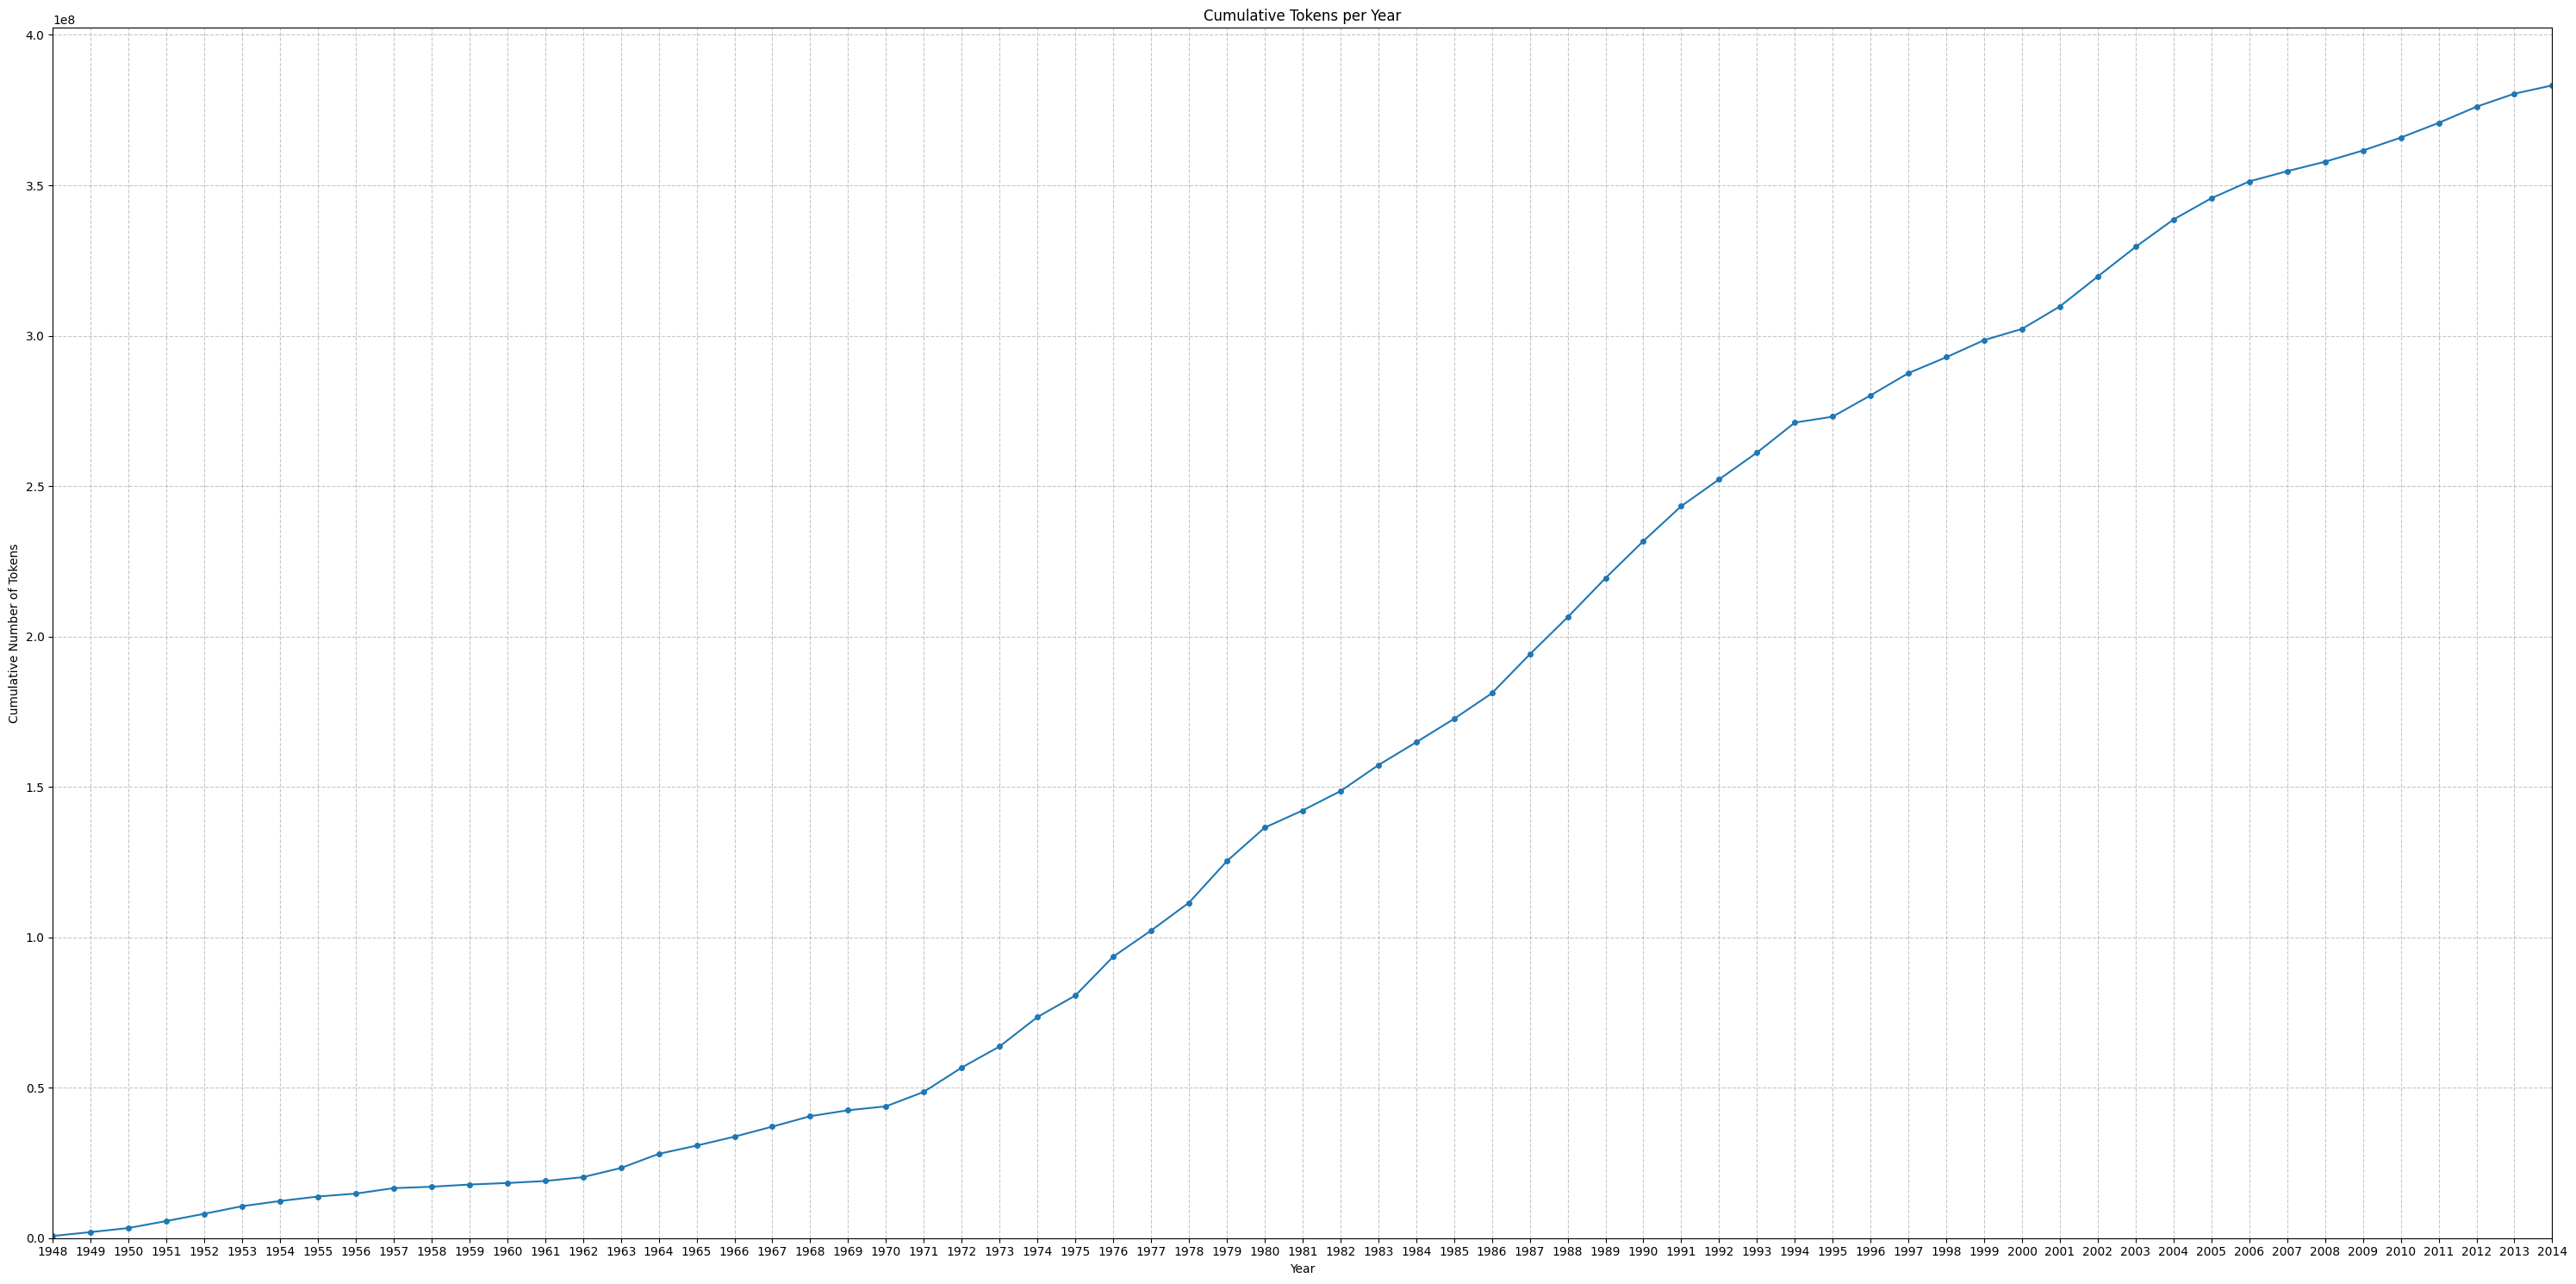

In [ ]:
# plot cumulative statistics

# compute cumulative number of tokens per year
input_dir = Path("../year_clean")
token_counts = []
years = []
for file in sorted(input_dir.iterdir()):
    year = file.stem.split("_")[-1]  # un_1949 -> 1949
    with open(file, "r", encoding="utf-8") as f:
        text = f.read()
    tokens = re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)
    token_counts.append(len(tokens))
    cumulative_counts = pd.Series(token_counts).cumsum()
    years.append(year)
# plot
plt.figure(figsize=(30, 15))
plt.plot(years, cumulative_counts, marker='o', markersize=4, linestyle='-')
plt.xlabel("Year")
plt.ylabel("Cumulative Number of Tokens")
plt.title("Cumulative Tokens per Year")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(left=years[0], right=years[-1])
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


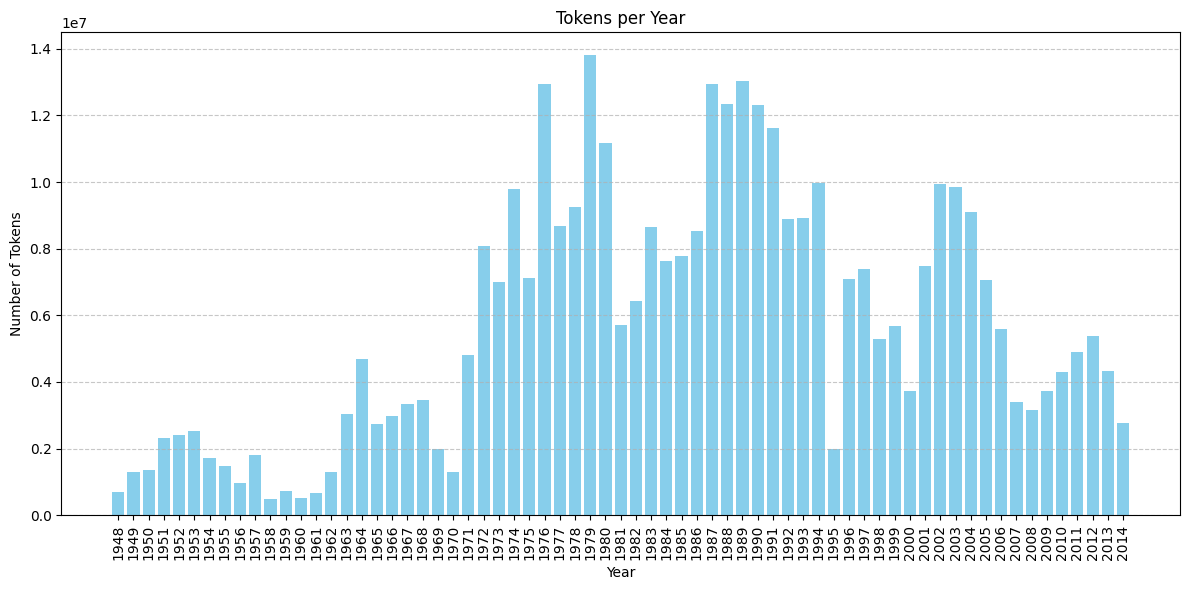

In [9]:
# histogram of tokens per year
import matplotlib.pyplot as plt
from pathlib import Path
import re
import pandas as pd
# compute number of tokens per year
input_dir = Path("../year_clean")
tokens_per_year = {}
for file in sorted(input_dir.iterdir()):
    year = file.stem.split("_")[-1]  # un_1949 -> 1949
    with open(file, "r", encoding="utf-8") as f:
        text = f.read()
    tokens = re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)
    tokens_per_year[year] = len(tokens)
    # years.append(year)
# plot histogram
plt.figure(figsize=(12, 6))
plt.bar(tokens_per_year.keys(), tokens_per_year.values(), color='skyblue')
plt.xlabel("Year")
plt.ylabel("Number of Tokens")
plt.title("Tokens per Year")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


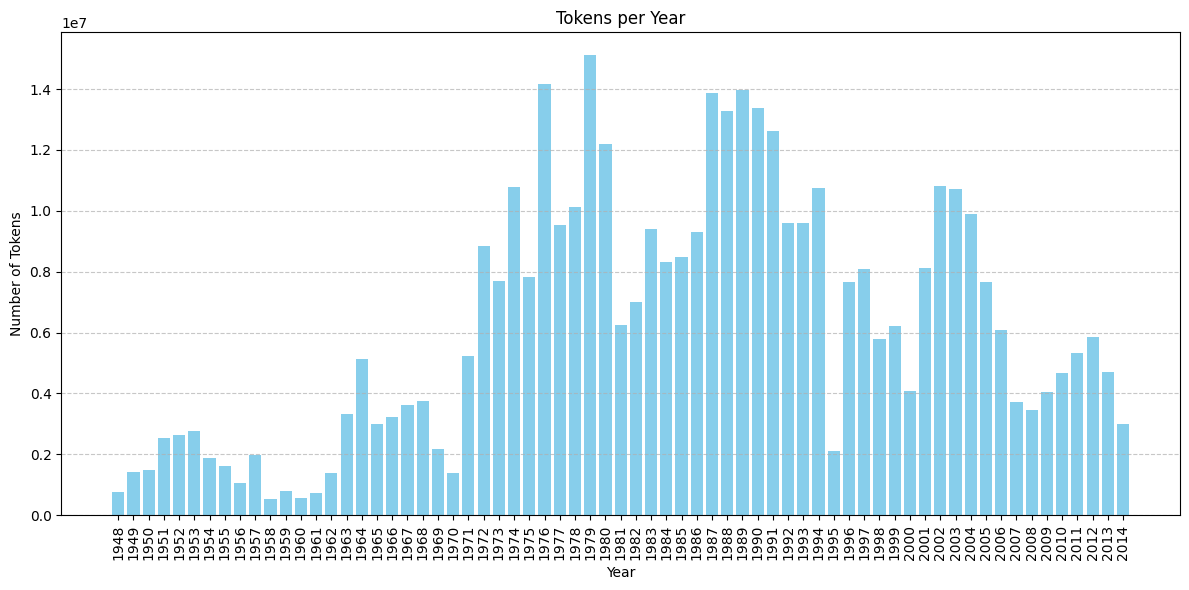

In [ ]:
# bar plot of tokens per year

# compute number of tokens per year
input_dir = Path("../lemmas")   
tokens_per_year = {}

for file in sorted(input_dir.iterdir()):
    # lemmas/un_2014_clean.txt_lemmas.txt
    year = file.name.split("_")[1]
    
    with open(file, "r", encoding="utf-8") as f:
        text = f.read()
    
    tokens = re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)
    tokens_per_year[year] = len(tokens)
    # years.append(year)

# plot
plt.figure(figsize=(12, 6))
plt.bar(tokens_per_year.keys(), tokens_per_year.values(), color="skyblue")
plt.xlabel("Year")
plt.ylabel("Number of Tokens")
plt.title("Tokens per Year")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()




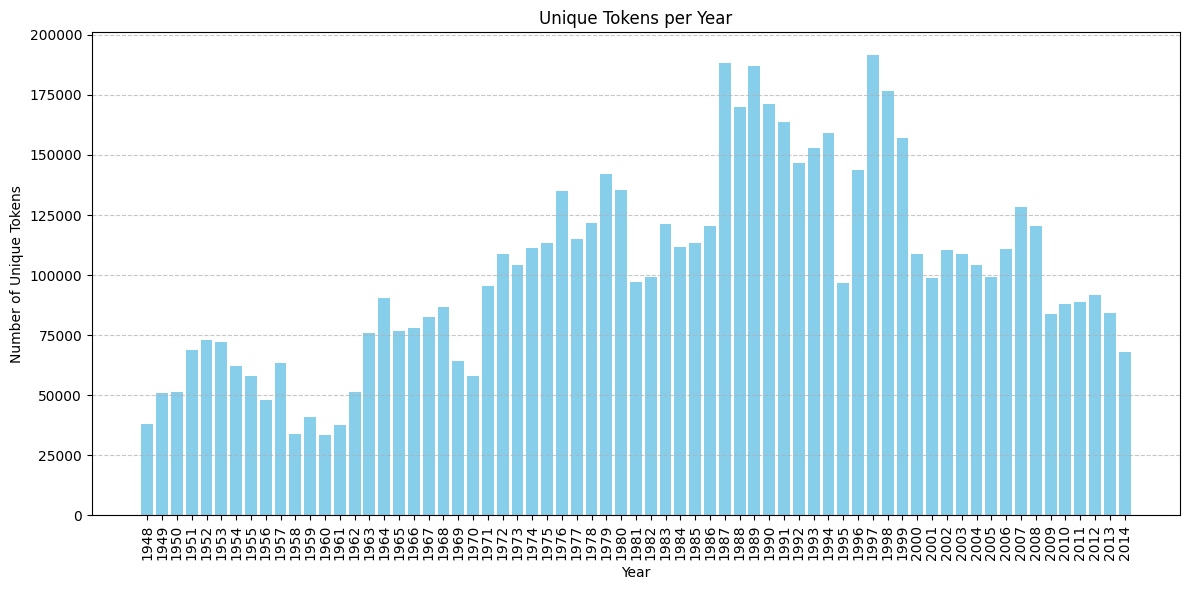

In [ ]:
# bar plot of unique tokens per year

# compute number of unique tokens per year
input_dir = Path("../lemmas")
unique_tokens_per_year = {}

for file in sorted(input_dir.iterdir()):
    # esempio: un_2014_clean.txt_lemmas.txt
    year = file.name.split("_")[1]

    with open(file, "r", encoding="utf-8") as f:
        text = f.read()

    tokens = re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)
    unique_tokens = set(tokens)
    unique_tokens_per_year[year] = len(unique_tokens)

# plot
plt.figure(figsize=(12, 6))
plt.bar(unique_tokens_per_year.keys(),
        unique_tokens_per_year.values(),
        color="skyblue")

plt.xlabel("Year")
plt.ylabel("Number of Unique Tokens")
plt.title("Unique Tokens per Year")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
def token_stats_per_year(input_dir):

    input_dir = Path(input_dir)
    stats = {}

    for file in sorted(input_dir.iterdir()):
        year = file.name.split("_")[1]

        with open(file, "r", encoding="utf-8") as f:
            text = f.read()

        tokens = re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)

        stats[year] = {
            "total": len(tokens),
            "unique": len(set(tokens))
        }

    return stats

stats = token_stats_per_year("../lemmas")

for year in sorted(stats):
    print(year,
          stats[year]["total"],
          stats[year]["unique"])


1948 767014 37933
1949 1406827 51046
1950 1483751 51239
1951 2546183 69004
1952 2631017 72863
1953 2758042 72191
1954 1875119 62141
1955 1631215 58082
1956 1067796 48159
1957 1983255 63242
1958 518396 33623
1959 791230 40837
1960 553747 33507
1961 727919 37517
1962 1400692 51216
1963 3310100 75842
1964 5144789 90511
1965 2996168 76620
1966 3239297 78003
1967 3633017 82739
1968 3767722 86576
1969 2164558 64018
1970 1379742 58109
1971 5242930 95332
1972 8842117 108974
1973 7679423 104064
1974 10770122 111420
1975 7816683 113380
1976 14167884 135003
1977 9532791 115103
1978 10109503 121881
1979 15107250 141943
1980 12206433 135530
1981 6241257 96992
1982 7019281 99094
1983 9418471 121088
1984 8320971 111566
1985 8474624 113321
1986 9297058 120628
1987 13872033 188479
1988 13280220 170100
1989 13965483 186940
1990 13385616 171160
1991 12632493 163823
1992 9615645 146697
1993 9608035 152922
1994 10764211 159155
1995 2120501 96884
1996 7646096 143843
1997 8081966 191494
1998 5799676 176754
1

## 3. Looking for the best split in order to have representative samples in each snapshot

In [6]:
import numpy as np
import pandas as pd
# Dati: (anno, token_totali)
data = [
    (1948, 767014),(1949, 1406827),
    (1950, 1483751),(1951, 2546183),(1952, 2631017),
    (1953, 2758042),(1954, 1875119),(1955, 1631215),(1956, 1067796),(1957, 1983255),
    (1958, 518396),(1959, 791230),
    (1960, 553747),(1961, 727919),(1962, 1400692),
    (1963, 3310100),(1964, 5144789),(1965, 2996168),(1966, 3239297),(1967, 3633017),
    (1968, 3767722),(1969, 2164558),(1970, 1379742),(1971, 5242930),(1972, 8842117),
    (1973, 7679423),(1974, 10770122),(1975, 7816683),(1976, 14167884),(1977, 9532791),
    (1978, 10109503),(1979, 15107250),(1980, 12206433),(1981, 6241257),(1982, 7019281),
    (1983, 9418471),(1984, 8320971),(1985, 8474624),(1986, 9297058),(1987, 13872033),
    (1988, 13280220),(1989, 13965483),(1990, 13385616),(1991, 12632493),(1992, 9615645),
    (1993, 9608035),(1994, 10764211),(1995, 2120501),(1996, 7646096),(1997, 8081966),
    (1998, 5799676),(1999, 6215994),(2000, 4092108),(2001, 8126281),(2002, 10802634),
    (2003, 10705415),(2004, 9887299),(2005, 7671983),(2006, 6078783),(2007, 3723349),
    (2008, 3457057),(2009, 4049666),(2010, 4678743),(2011, 5322646),(2012, 5849452),
    (2013, 4706196),(2014, 3004416)
]

def find_best_partition(data, min_k=5, max_k=10):
    best_config = None
    min_cv = float('inf') # Coefficiente di Variazione (vogliamo minimizzarlo)

    total_sum = sum(x[1] for x in data)

    # Proviamo diversi numeri di gruppi (K)
    for k in range(min_k, max_k + 1):
        target_size = total_sum / k
        
        groups = []
        current_group_years = []
        current_group_sum = 0
        
        # Iteriamo sugli anni
        for i, (year, tokens) in enumerate(data):
            current_group_years.append(year)
            current_group_sum += tokens
            
            # DECISIONE DI TAGLIO (Lookahead)
            # Dobbiamo decidere se chiudere il gruppo QUI o aggiungere il prossimo anno.
            # Regola: Chiudiamo se siamo più vicini al target ORA rispetto a se aggiungessimo il prossimo.
            
            if i < len(data) - 1:
                next_tokens = data[i+1][1]
                # Distanza dal target se chiudo ora
                diff_now = abs(current_group_sum - target_size)
                # Distanza dal target se aggiungo il prossimo
                diff_next = abs((current_group_sum + next_tokens) - target_size)
                
                # Se chiudere ora è meglio (o uguale) che continuare, e non siamo all'ultimo gruppo forzato
                if diff_now < diff_next and len(groups) < k - 1:
                    groups.append({
                        'years': f"{current_group_years[0]}-{current_group_years[-1]}",
                        'start': current_group_years[0],
                        'end': current_group_years[-1],
                        'tokens': current_group_sum,
                        'n_years': len(current_group_years)
                    })
                    # Reset
                    current_group_years = []
                    current_group_sum = 0
            else:
                # Siamo all'ultimo elemento, chiudiamo tutto nel gruppo finale
                groups.append({
                    'years': f"{current_group_years[0]}-{current_group_years[-1]}",
                    'start': current_group_years[0],
                    'end': current_group_years[-1],
                    'tokens': current_group_sum,
                    'n_years': len(current_group_years)
                })

        # Calcolo statistiche per questo K
        tokens_list = [g['tokens'] for g in groups]
        mean_tokens = np.mean(tokens_list)
        std_tokens = np.std(tokens_list)
        cv = std_tokens / mean_tokens # Coefficient of Variation (normalizzato)

        # Se questa configurazione è più bilanciata della precedente, salvala
        if cv < min_cv:
            min_cv = cv
            best_config = {
                'k': len(groups),
                'groups': groups,
                'std': std_tokens,
                'mean': mean_tokens,
                'cv': cv
            }

    return best_config

# ESECUZIONE
best = find_best_partition(data, min_k=5, max_k=10)

# Output
if best:
    print(f"\n--- MIGLIORE CONFIGURAZIONE TROVATA: {best['k']} SNAPSHOT ---")
    print(f"Target Ideale per gruppo: ~{int(best['mean']):,} token")
    print(f"Deviazione Standard: {int(best['std']):,} (CV: {best['cv']:.2%})\n")
    
    df_res = pd.DataFrame(best['groups'])
    df_res['diff_from_mean_%'] = ((df_res['tokens'] - best['mean']) / best['mean']) * 100
    
    # Formattazione
    pd.options.display.float_format = '{:,.0f}'.format
    print(df_res[['years', 'n_years', 'tokens', 'diff_from_mean_%']].to_string(index=False))
    
    # GENERAZIONE LISTA TUPLE PER IL TUO CODICE
    print("snapshots_ranges = [")
    for g in best['groups']:
        print(f"    ({g['start']}, {g['end']}),  # {int(g['tokens']/1e6)}M token")
    print("]")


--- MIGLIORE CONFIGURAZIONE TROVATA: 7 SNAPSHOT ---
Target Ideale per gruppo: ~59,595,484 token
Deviazione Standard: 1,441,455 (CV: 2.42%)

    years  n_years   tokens  diff_from_mean_%
1948-1972       25 61862643                 4
1973-1978        6 60076406                 1
1979-1984        6 58313663                -2
1985-1989        5 58889418                -1
1990-1995        6 58126501                -2
1996-2003        8 61470170                 3
2004-2014       11 58429590                -2

--- DA COPIARE NEL TUO CODICE ---
snapshots_ranges = [
    (1948, 1972),  # 61M token
    (1973, 1978),  # 60M token
    (1979, 1984),  # 58M token
    (1985, 1989),  # 58M token
    (1990, 1995),  # 58M token
    (1996, 2003),  # 61M token
    (2004, 2014),  # 58M token
]


In [10]:
# salvataggio degli snapshot con tutti i lemmi degli anni in gruppi bilanciati

# Cartella dei file originali
input_dir = Path("../lemmas")
output_dir = Path("../lemmas/snaps")
output_dir.mkdir(exist_ok=True)

# Definizione dei gruppi con anni inclusi
groups = [
    (1, range(1948, 1973)),  # 1948-1972
    (2, range(1973, 1979)),  # 1973-1978
    (3, range(1979, 1985)),  # 1979-1984
    (4, range(1985, 1990)),  # 1985-1989
    (5, range(1990, 1996)),  # 1990-1995
    (6, range(1996, 2004)),  # 1996-2003
    (7, range(2004, 2015)),  # 2004-2014
]

# Ciclo sui gruppi
for snap_num, years in groups:
    output_file = output_dir / f"snap{snap_num}.txt"
    
    with open(output_file, "w", encoding="utf-8") as out_f:
        for year in years:
            # Cerca file corrispondente all'anno
            # un_1960_clean.txt_lemmas.txt
            file_pattern = f"*_{year}_*_lemmas.txt"
            matches = list(input_dir.glob(file_pattern))
            if not matches:
                print(f"Attenzione: nessun file trovato per l'anno {year}")
                continue
            for file_path in matches:
                with open(file_path, "r", encoding="utf-8") as f:
                    content = f.read()
                    out_f.write(content + "\n")  # unisco i testi

    print(f"Creato {output_file} con anni {min(years)}-{max(years)}")


Creato ..\lemmas\snaps\snap1.txt con anni 1948-1972
Creato ..\lemmas\snaps\snap2.txt con anni 1973-1978
Creato ..\lemmas\snaps\snap3.txt con anni 1979-1984
Creato ..\lemmas\snaps\snap4.txt con anni 1985-1989
Creato ..\lemmas\snaps\snap5.txt con anni 1990-1995
Creato ..\lemmas\snaps\snap6.txt con anni 1996-2003
Creato ..\lemmas\snaps\snap7.txt con anni 2004-2014
